In [ ]:
import pandas as pd
import numpy as np

sensor_record = pd.read_csv("data_X.csv")
sensor_record

In [ ]:
quality_record = pd.read_csv("data_Y.csv")
quality_record

In [ ]:
sensor_record['date_time']

# Datatype

### Checking the datatype

In [ ]:
print(sensor_record.info())     # Checking the datatype

print(sensor_record['date_time'].dtypes)     # Check data type of a specific column

print(type(sensor_record['date_time'][0]))     # Check data type of a specific value

### Changing the format to datetime

In [ ]:
sensor_record['date_time'] = pd.to_datetime(sensor_record['date_time'])
quality_record['date_time'] = pd.to_datetime(quality_record['date_time'])

print(sensor_record['date_time'].dtypes)
print(sensor_record['date_time'].dtypes)

### Sorting the datasets

In [ ]:
sensor_record = sensor_record.sort_values('date_time')
quality_record = quality_record.sort_values('date_time')

### Set datetime as index 

Why? coz it unlocks 
- Resampling  --> resample('h').mean()
- Time filtering --> df.loc['2026-05']
- Rolling windows --> df.rolling('2h').mean()

In [ ]:
sensor_record = sensor_record.set_index('date_time')
quality_record = quality_record.set_index('date_time')

print(sensor_record)
print(quality_record)

### Resampling

In [ ]:
sensor_hr_record = sensor_record.resample('h').mean().round().astype(int)
sensor_hr_record

### Merging

In [ ]:
combined_df = pd.merge_asof(sensor_hr_record, quality_record, on = 'date_time', direction = 'nearest')

## Understanding the final dataset

- df.shape --> (rows, columns)

In [ ]:
combined_df.shape

- df.head() --> getting top n rows

In [ ]:
combined_df.head(6)

- df.info() --> getting info of columns

In [ ]:
combined_df.info()

- df.describe() --> gives statistical summary of the DataFrame columns

In [ ]:
combined_df.describe()

### Check for the missing values

In [ ]:
combined_df.isnull().sum()

### Finding Correlation (the joint variablity of two data series)

*correlation = covariance(x,y) ÷ (std_df1 × std_df2)*

Tells direction + strength

- +1 --> both are increasing (strong relation)
- -1 --> one decreasing other increasing (weak relation)
-  0 --> No meaningful relation

In [ ]:
corr_df = combined_df.corr()

corr_df

--> How strongly each Chamber's sensor is related to the quality?

In [ ]:
quality_corr = corr_df['quality'].drop('date_time').sort_values(ascending = False)

quality_corr

# Usually we remove self-correlation and unnecessary relations:

## Insight:

Chamber 3 Sensors
- T_data_3_3 =  -0.567835
- T_data_3_1 =  -0.552030
- T_data_3_2 =  -0.549581

These have the strongest correlations with quality.

And they are negative.

This means:

As Chamber 3 temperature increases, quality decreases.

It suggests:

- Chamber 3 temperature may be affecting defects
- Overheating might reduce quality
- Chamber 3 could be unstable or sensitive

Since all 3 sensors from Chamber 3 show similar behavior the pattern is probably real and not random noise that strengthens confidence.

All the other chambers has less or no effect on quality.

# Visualization

### Correlation Heatmap

“Which sensors are related to production quality?”

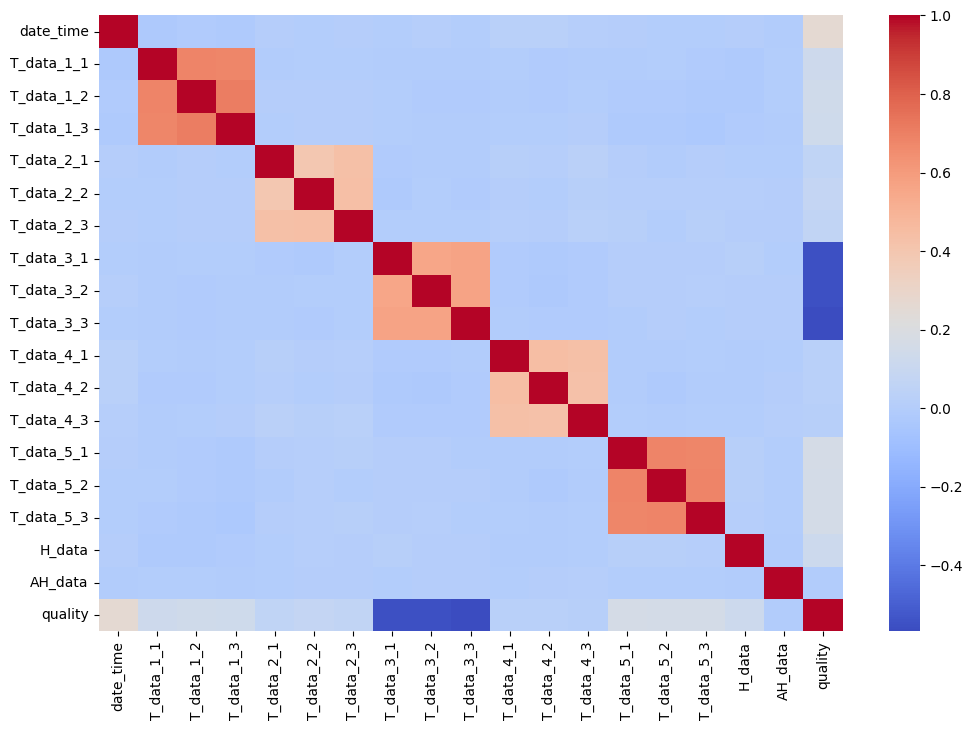

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_df, cmap = 'coolwarm')
plt.show()

Chamber 3 Sensors Have Negative Correlation With Quality

- T_data_3_1
- T_data_3_2
- T_data_3_3

These show DARK BLUE with quality.

So, As Chamber 3 sensor values increase, quality decreases.

## Regression Plot

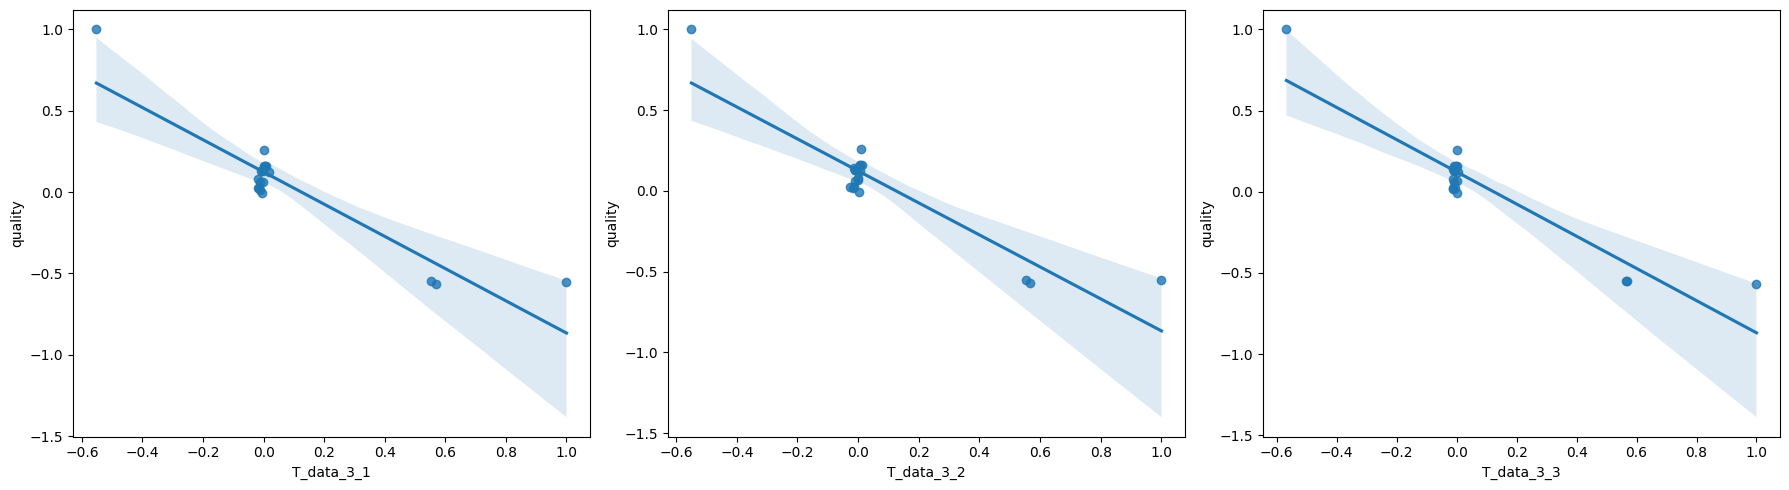

In [102]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.regplot(
    x='T_data_3_1',
    y='quality',
    data=corr_df,
    ax=axes[0]
)

sns.regplot(
    x='T_data_3_2',
    y='quality',
    data=corr_df,
    ax=axes[1]
)

sns.regplot(
    x='T_data_3_3',
    y='quality',
    data=corr_df,
    ax=axes[2]
)

plt.tight_layout()
plt.show()

*Insight* :- Chamber 3 may have process instability or operational conditions negatively affecting production quality.

**Real Interpretation**

Your heatmap is likely helping you discover:

- Chamber 3 temperatures strongly relate to quality
- Chamber 3 sensors correlate with each other
- Some chambers have almost no impact
- Humidity may not matter much

# Rolling standard

This helps detect:

- instability
- process drift
- abnormal behavior

-> "How much the sensor values are fluctuating over time"

In [121]:
combined_df['T3_1_std'] = combined_df['T_data_3_1'].rolling(10).std()
combined_df['T3_2_std'] = combined_df['T_data_3_2'].rolling(10).std()
combined_df['T3_3_std'] = combined_df['T_data_3_3'].rolling(10).std()

In [119]:
# combined_df = combined_df.set_index('date_time')

combined_df

,T_data_1_1,T_data_1_2,T_data_1_3,T_data_2_1,T_data_2_2,T_data_2_3,T_data_3_1,T_data_3_2,T_data_3_3,T_data_4_1,...,T_data_4_3,T_data_5_1,T_data_5_2,T_data_5_3,H_data,AH_data,quality,T3_1_std,T3_2_std,T3_3_std
date_time,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,213,214,211,321,329,344,502,473,486,367,...,350,247,241,240,165,9,392,NaN,NaN,NaN
2015-01-01 01:00:00,210,205,213,290,271,355,529,476,491,345,...,344,238,239,238,165,8,392,NaN,NaN,NaN
2015-01-01 02:00:00,231,191,210,291,312,342,510,489,487,359,...,344,238,232,239,165,6,392,NaN,NaN,NaN
2015-01-01 03:00:00,228,222,223,326,153,344,457,474,481,338,...,350,236,240,237,165,8,392,NaN,NaN,NaN
2015-01-01 04:00:00,236,240,250,347,256,346,424,481,484,336,...,355,240,242,239,165,7,392,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 20:00:00,252,265,256,379,368,379,474,449,468,331,...,323,277,281,276,186,6,454,25.188181,14.810282,26.718491
2018-12-31 21:00:00,302,284,255,359,355,354,481,449,492,326,...,326,277,279,279,164,8,454,27.395052,13.706851,29.047088
2018-12-31 22:00:00,294,273,259,355,355,355,481,449,493,325,...,327,277,276,280,160,6,454,29.753805,14.087425,30.919968


Higher rolling standard deviation = higher fluctuation/instability in the sensor values.

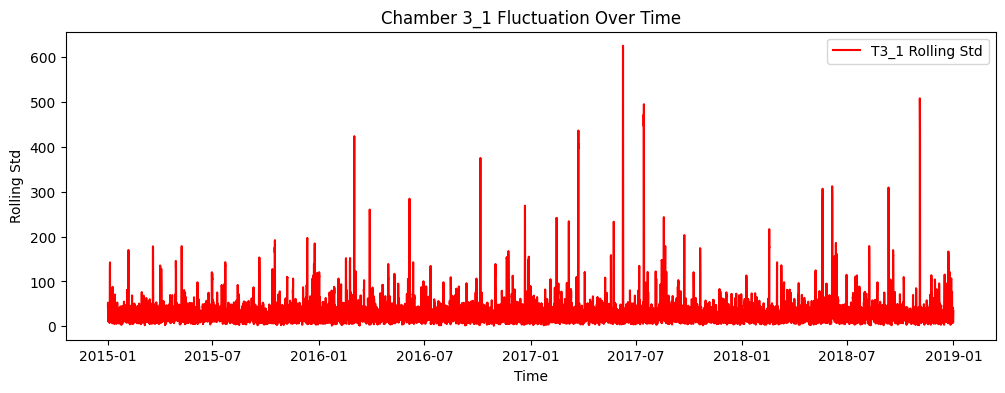

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(combined_df['T3_1_std'], label='T3_1 Rolling Std', color = 'Red')

plt.title('Chamber 3_1 Fluctuation Over Time')
plt.xlabel('Time')
plt.ylabel('Rolling Std')

plt.legend()
plt.show()

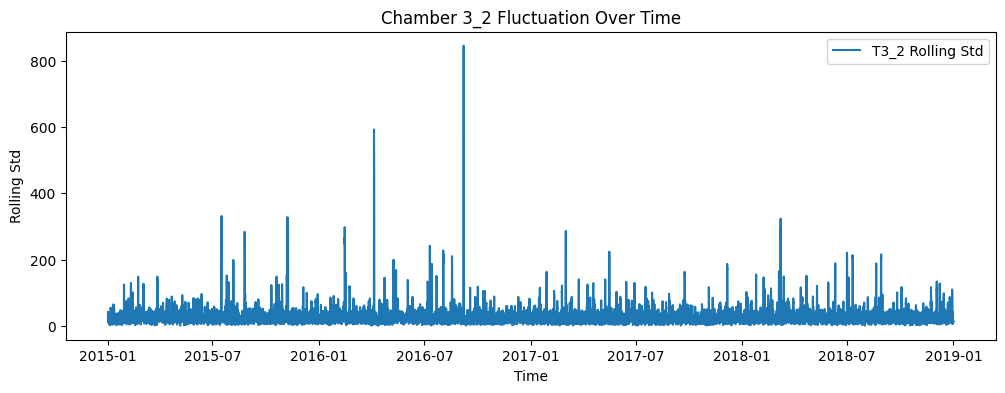

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(combined_df['T3_2_std'], label='T3_2 Rolling Std')

plt.title('Chamber 3_2 Fluctuation Over Time')
plt.xlabel('Time')
plt.ylabel('Rolling Std')

plt.legend()
plt.show()

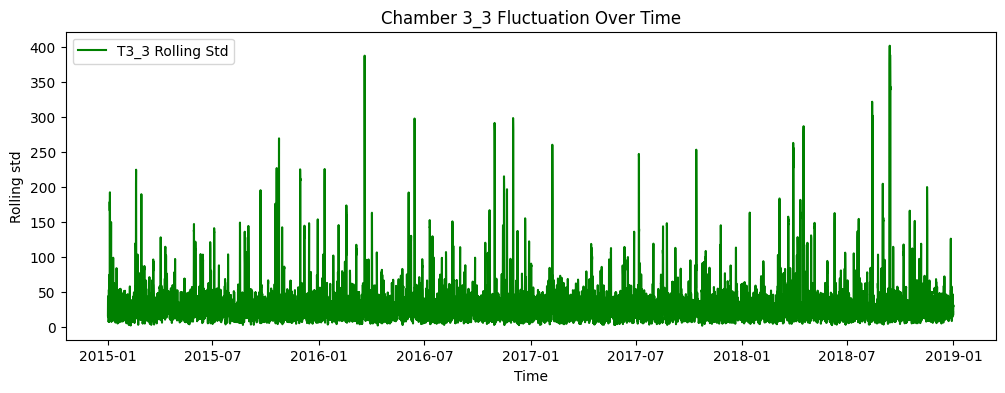

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(combined_df['T3_3_std'], label = 'T3_3 Rolling Std', color='Green')

plt.title('Chamber 3_3 Fluctuation Over Time')
plt.xlabel('Time')
plt.ylabel('Rolling std')

plt.legend()
plt.show()

Small Spike

Maybe:
1. temporary disturbance
2. minor variation

Large Spike

Possibility:

1. overheating
2. cooling issue
3. sensor instability
4. machine malfunction
5. process transition

| Pattern                    | Meaning               |
| -------------------------- | --------------------- |
| Sudden rise in rolling std | Instability           |
| Repeated spikes            | Process inconsistency |
| Spike before defects       | Potential root cause  |
| Long unstable region       | Process drift         |
